# Experiment 0 — 最小枚举实验 (minimal enumeration)

**这是第一件必须做的事情。** 在任何真实数据、任何 amortized inference、任何 EM 之前，
先在一个小到可以**完全枚举**的模型上，验证 posterior 计算本身是对的。

**Goal.** Build a segmentation model so small that the exact posterior over *all*
latent segmentations can be computed by brute force, then check that
(a) the dynamic program and (b) the MCMC sampler both reproduce it.

**Setup.** $K=2$ skills, $V=5$ action types, $T \le 8$ steps.

$$
A=\{\texttt{SEARCH},\texttt{READ}\},\qquad B=\{\texttt{EDIT},\texttt{TEST}\}
$$

with trace $c = (\texttt{SEARCH},\texttt{READ},\texttt{EDIT},\texttt{TEST})$ whose
true segmentation is $[\texttt{SEARCH},\texttt{READ}]_A \mid [\texttt{EDIT},\texttt{TEST}]_B$.

**成功标准 (gate).** Over every boundary position $j$ and every segment cell $(a,b,k)$:

$$
\bigl|P_{\mathrm{MCMC}}(B_j{=}1) - P_{\mathrm{exact}}(B_j{=}1)\bigr| < 0.02,
\qquad
\bigl|\hat\gamma_{\mathrm{MCMC}}(a,b,k) - \gamma_{\mathrm{exact}}(a,b,k)\bigr| < 0.02 .
$$

**这一关没通过，不能继续后面的实验。** The notebook prints an explicit PASS/FAIL gate at the end.

Three independent implementations are compared, which is the whole point:

| engine | cost | what it is |
|---|---|---|
| `enumerate_exact` | $O(\sum_B K^{L(B)})$ | brute force over every $(B, z)$ — the ground truth |
| `dp_exact` | $O(T^2K)$ | semi-Markov forward–backward — the thing we actually want to trust |
| `gibbs` | $O(NT)$ | collapsed Gibbs on the boundary variables — the thing that must scale later |

`enumerate_exact` vs `dp_exact` must agree to **machine precision** (both are exact).
`gibbs` vs `enumerate_exact` must agree to **Monte-Carlo precision** (the 0.02 gate).

## 1. The model

### Latent variable

A full segmentation is an ordered list of labelled segments

$$
S=[(a_1,b_1,z_1),\dots,(a_L,b_L,z_L)],\qquad
a_1=1,\; b_L=T,\; a_{l+1}=b_l+1,
$$

e.g. $S=[(1,2,A),(3,4,B)]$. Indices are **1-based and inclusive**, matching the spec.

### Likelihood — 最简单的版本

Each skill carries one fixed composition distribution
$\phi_k=(\phi_{k1},\dots,\phi_{kV})$ with $\phi_{kv}=P(c_t=v\mid z=k)$.
A segment's likelihood is a bag of actions — **no within-segment order model at all**
(that is the point of "最简单"; order comes back in later experiments via the
frontier-softmax / partial-order likelihood):

$$
p(c_{a:b}\mid z=k,\phi_k)=\prod_{t=a}^{b}\phi_{k,c_t}.
$$

### Boundary prior

第一版没有 duration parameter. To make the segmentation posterior a proper
distribution we put an i.i.d. Bernoulli prior on the boundary indicators.
For $j=1,\dots,T-1$ let $B_j=\mathbb{1}[\text{there is a boundary after position } j]$:

$$
B_j \overset{\text{iid}}{\sim} \mathrm{Bernoulli}(\rho),
\qquad
p(B)=\rho^{m}(1-\rho)^{T-1-m},\quad m=\textstyle\sum_j B_j .
$$

$B$ and $S$ are in bijection once labels are attached, so this is a proper prior over
segmentations: $L = m+1$, and the segment set is determined by where the 1s are.

### Labels

$z_l \overset{\text{iid}}{\sim} \mathrm{Categorical}(\pi)$, $\pi$ uniform over $K=2$.
No no-self-transition constraint in the main model (that variant is Appendix A).

### Joint

$$
\log p(c,B,z)
= \underbrace{m\log\rho + (T{-}1{-}m)\log(1{-}\rho)}_{\log p(B)}
+ \sum_{l=1}^{L}\Bigl[\log\pi_{z_l} + \sum_{t=a_l}^{b_l}\log\phi_{z_l,c_t}\Bigr].
$$

Everything below is exactly this expression — nothing else.

In [1]:
%matplotlib inline
import itertools, json, math, time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

SEED = 0

# ---- plot style: recessive axes, thin marks, muted ink -------------------------------
S1, S2, S3 = "#2a78d6", "#eb6834", "#1baf7a"     # categorical slots 1-3 (validated all-pairs)
INK, INK2, INK3 = "#0b0b0b", "#52514e", "#8f8e88"
plt.rcParams.update({
    "figure.dpi": 130, "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": INK3, "axes.linewidth": 0.8,
    "axes.labelcolor": INK2, "axes.titlecolor": INK, "axes.titlesize": 11,
    "axes.titlelocation": "left", "axes.titleweight": "bold", "axes.labelsize": 9,
    "xtick.color": INK2, "ytick.color": INK2, "xtick.labelsize": 8.5, "ytick.labelsize": 8.5,
    "xtick.major.size": 0, "ytick.major.size": 0,
    "grid.color": "#e6e5e0", "grid.linewidth": 0.8,
    "legend.frameon": False, "legend.fontsize": 8.5,
    "lines.linewidth": 2.0, "font.size": 9,
})

In [2]:
# ---- vocabulary, skills, parameters -------------------------------------------------
VOCAB  = ["SEARCH", "READ", "EDIT", "TEST", "OTHER"]      # V = 5
SKILLS = ["A", "B"]                                        # K = 2
V, K   = len(VOCAB), len(SKILLS)
VID    = {w: i for i, w in enumerate(VOCAB)}

# A = {SEARCH, READ}, B = {EDIT, TEST}; OTHER is shared so the posterior is not trivial.
PHI = np.array([
    [0.45, 0.35, 0.05, 0.05, 0.10],   # phi_A
    [0.05, 0.05, 0.45, 0.35, 0.10],   # phi_B
])
PI  = np.array([0.5, 0.5])            # label prior
RHO = 0.3                             # P(boundary) at each of the T-1 gaps

assert np.allclose(PHI.sum(1), 1) and np.allclose(PI.sum(), 1)
LOG_PHI, LOG_PI = np.log(PHI), np.log(PI)
LOG_RHO, LOG_1MRHO = math.log(RHO), math.log1p(-RHO)

print(f"V={V}  K={K}  rho={RHO}")
print("phi:")
print("      " + "".join(f"{w:>9}" for w in VOCAB))
for k in range(K):
    print(f"  {SKILLS[k]}:  " + "".join(f"{PHI[k, v]:9.2f}" for v in range(V)))

V=5  K=2  rho=0.3
phi:
         SEARCH     READ     EDIT     TEST    OTHER
  A:       0.45     0.35     0.05     0.05     0.10
  B:       0.05     0.05     0.45     0.35     0.10


In [3]:
# ---- the traces ---------------------------------------------------------------------
TRACE1 = ["SEARCH", "READ", "EDIT", "TEST"]                       # T = 4, the spec's trace
TRUTH1 = [(1, 2, 0), (3, 4, 1)]                                   # [SEARCH READ]_A | [EDIT TEST]_B

# a harder T=8 trace: the ambiguous OTHER tokens sit exactly where the boundaries are,
# so the posterior is genuinely spread over several segmentations.
TRACE2 = ["SEARCH", "READ", "OTHER", "EDIT", "TEST", "OTHER", "SEARCH", "READ"]
TRUTH2 = [(1, 3, 0), (4, 6, 1), (7, 8, 0)]

def encode(trace):
    return np.array([VID[w] for w in trace], dtype=int)

def show_trace(trace, truth=None, name=""):
    print(f"{name}  T={len(trace)}")
    print("  t :  " + "  ".join(f"{t+1:^6d}" for t in range(len(trace))))
    print("  c :  " + "  ".join(f"{w[:6]:^6s}" for w in trace))
    if truth is not None:
        row = ["      "] * len(trace)
        for a, b, k in truth:
            for t in range(a - 1, b):
                row[t] = f"{SKILLS[k]:^6s}"
        print("  z*:  " + "  ".join(row))

show_trace(TRACE1, TRUTH1, "TRACE1")
print()
show_trace(TRACE2, TRUTH2, "TRACE2")

TRACE1  T=4
  t :    1       2       3       4   
  c :  SEARCH   READ    EDIT    TEST 
  z*:    A       A       B       B   

TRACE2  T=8
  t :    1       2       3       4       5       6       7       8   
  c :  SEARCH   READ   OTHER    EDIT    TEST   OTHER   SEARCH   READ 
  z*:    A       A       A       B       B       B       A       A   


## 2. Representation & the joint

`B` is a tuple of $T-1$ bits; `segments_from_boundaries` turns it into the segment list.
Every quantity below is derived from **one** function, `log_joint`, so the three engines
cannot silently disagree about what the model is.

`seg_ll[a-1, b-1, k]` caches $\sum_{t=a}^{b}\log\phi_{k,c_t}$ via a cumulative sum.

In [4]:
def segments_from_boundaries(bits):
    """bits[j] = B_{j+1} in {0,1}, length T-1  ->  [(a, b), ...] 1-based inclusive."""
    segs, a = [], 1
    for j, bit in enumerate(bits, start=1):
        if bit:
            segs.append((a, j)); a = j + 1
    segs.append((a, len(bits) + 1))
    return segs

def boundaries_from_segments(segs, T):
    bits = [0] * (T - 1)
    for a, b in segs:
        if b < T:
            bits[b - 1] = 1
    return tuple(bits)

def seg_loglik_table(c):
    """LL[a-1, b-1, k] = sum_{t=a..b} log phi[k, c_t]; -inf if b < a."""
    T = len(c)
    cum = np.zeros((T + 1, K))                     # cum[t, k] = sum of first t steps
    for t in range(T):
        cum[t + 1] = cum[t] + LOG_PHI[:, c[t]]
    LL = np.full((T, T, K), -np.inf)
    for a in range(1, T + 1):
        for b in range(a, T + 1):
            LL[a - 1, b - 1] = cum[b] - cum[a - 1]
    return LL

def log_prior_boundaries(bits):
    m = int(sum(bits))
    return m * LOG_RHO + (len(bits) - m) * LOG_1MRHO

def log_joint(bits, labels, LL):
    """log p(c, B, z) for one complete state."""
    segs = segments_from_boundaries(bits)
    assert len(segs) == len(labels)
    t = log_prior_boundaries(bits)
    for (a, b), k in zip(segs, labels):
        t += LOG_PI[k] + LL[a - 1, b - 1, k]
    return t

# sanity: the true state of TRACE1
LL1 = seg_loglik_table(encode(TRACE1))
print("log p(c, B*, z*) for TRACE1 =", round(log_joint((0, 1, 0), (0, 1), LL1), 4))

log p(c, B*, z*) for TRACE1 = -7.0003


## 3. Exact posterior by full enumeration

State space size is $\sum_{B} K^{L(B)} = \sum_{m=0}^{T-1}\binom{T-1}{m}K^{m+1} = K(K{+}1)^{T-1}$
— 54 states for $T=4$, 4374 for $T=8$. Enumerable, so we enumerate.

Quantities extracted:

* $P(B_j{=}1)$ — boundary marginals,
* $\gamma(a,b,k)=P\bigl((a,b,k)\in S \mid c\bigr)$ — segment marginals (the *cells* of the DP),
* the MAP segmentation and the posterior over the number of segments $L$.

In [5]:
def enumerate_states(T):
    """Yield every (bits, labels) pair."""
    for bits in itertools.product((0, 1), repeat=T - 1):
        L = sum(bits) + 1
        for labels in itertools.product(range(K), repeat=L):
            yield bits, labels

def exact_posterior(c):
    """Full enumeration. Returns dict with normalized posterior + all marginals."""
    T, LL = len(c), seg_loglik_table(c)
    states, logps = [], []
    for bits, labels in enumerate_states(T):
        states.append((bits, labels))
        logps.append(log_joint(bits, labels, LL))
    logps = np.array(logps)
    logZ = float(np.logaddexp.reduce(logps))
    post = np.exp(logps - logZ)

    pB = np.zeros(T - 1)
    gamma = np.zeros((T, T, K))
    pL = np.zeros(T + 1)
    for (bits, labels), p in zip(states, post):
        pB += p * np.array(bits, dtype=float)
        segs = segments_from_boundaries(bits)
        pL[len(segs)] += p
        for (a, b), k in zip(segs, labels):
            gamma[a - 1, b - 1, k] += p
    order = np.argsort(-post)
    return dict(T=T, LL=LL, states=states, post=post, logZ=logZ,
                pB=pB, gamma=gamma, pL=pL,
                map_state=states[order[0]], map_prob=float(post[order[0]]),
                order=order, n_states=len(states))

def fmt_state(bits, labels):
    segs = segments_from_boundaries(bits)
    return " | ".join(f"({a},{b},{SKILLS[k]})" for (a, b), k in zip(segs, labels))

ex1 = exact_posterior(encode(TRACE1))
print(f"TRACE1: {ex1['n_states']} states,  log Z = {ex1['logZ']:.4f}\n")
print("top-8 segmentations by posterior mass")
print(f"  {'p':>7}  segmentation")
for i in ex1["order"][:8]:
    bits, labels = ex1["states"][i]
    star = "  <- truth" if fmt_state(bits, labels) == "(1,2,A) | (3,4,B)" else ""
    print(f"  {ex1['post'][i]:7.4f}  {fmt_state(bits, labels)}{star}")

TRACE1: 54 states,  log Z = -6.2129

top-8 segmentations by posterior mass
        p  segmentation
   0.4550  (1,2,A) | (3,4,B)  <- truth
   0.0975  (1,2,A) | (3,3,B) | (4,4,B)
   0.0975  (1,1,A) | (2,2,A) | (3,4,B)
   0.0650  (1,1,A) | (2,4,B)
   0.0506  (1,3,A) | (4,4,B)
   0.0337  (1,4,B)
   0.0337  (1,4,A)
   0.0209  (1,1,A) | (2,2,A) | (3,3,B) | (4,4,B)


In [6]:
def print_pB(pB, T, label="P(B_j=1)"):
    print(label)
    print("   j :  " + "  ".join(f"{j:^6d}" for j in range(1, T)))
    print("   p :  " + "  ".join(f"{v:^6.3f}" for v in pB))

def print_gamma(gamma, T, thresh=1e-3, label="gamma(a,b,k)"):
    print(f"{label}   (cells with mass > {thresh})")
    rows = [(a + 1, b + 1, k, gamma[a, b, k])
            for a in range(T) for b in range(a, T) for k in range(K)
            if gamma[a, b, k] > thresh]
    rows.sort(key=lambda r: -r[3])
    for a, b, k, g in rows:
        print(f"   ({a},{b},{SKILLS[k]})  {g:6.4f}")

print_pB(ex1["pB"], ex1["T"])
print()
print_gamma(ex1["gamma"], ex1["T"])
print()
print("P(L = l):", {l: round(float(p), 4) for l, p in enumerate(ex1["pL"]) if p > 1e-4})
print("MAP     :", fmt_state(*ex1["map_state"]), f"  p = {ex1['map_prob']:.4f}")

P(B_j=1)
   j :    1       2       3   
   p :  0.271   0.755   0.257 

gamma(a,b,k)   (cells with mass > 0.001)
   (1,2,A)  0.5861
   (3,4,B)  0.5861
   (1,1,A)  0.2441
   (4,4,B)  0.2248
   (3,3,B)  0.1435
   (2,2,A)  0.1395
   (2,4,B)  0.0722
   (1,3,A)  0.0578
   (1,4,B)  0.0337
   (1,4,A)  0.0337
   (4,4,A)  0.0321
   (1,1,B)  0.0271
   (2,2,B)  0.0199
   (2,3,B)  0.0177
   (3,3,A)  0.0159
   (2,3,A)  0.0138
   (1,2,B)  0.0093
   (3,4,A)  0.0093
   (1,3,B)  0.0083
   (2,4,A)  0.0080

P(L = l): {1: 0.0674, 2: 0.6159, 3: 0.283, 4: 0.0337}
MAP     : (1,2,A) | (3,4,B)   p = 0.4550


**Read the numbers.** The MAP *is* the true segmentation and holds 45.5% of the mass —
recovery works. But the boundary marginals are more interesting than that headline:

$$
P(B_1{=}1)=0.271,\qquad P(B_2{=}1)=0.755,\qquad P(B_3{=}1)=0.257 .
$$

The real boundary is only at 0.755, and the two fake ones sit close to the prior
$\rho=0.3$. **That is the model being honest, not a bug.** Since self-transitions are
allowed, splitting $[\texttt{SEARCH READ}]_A$ into `(1,1,A)|(2,2,A)` gives *exactly the
same likelihood* — the data cannot see the difference, so those boundaries are governed
by the prior alone (a $\rho/(1-\rho)$ tug of war, plus the $\log\pi_k$ cost of an extra
label). Symmetrically, $P(B_2{=}1)$ leaks below 1 through single-segment states like
`(1,4,A)`, which explain the trace badly but not impossibly.

This is the standard non-identifiability of a segmentation model with no
no-self-transition constraint. It is worth seeing *here*, on 54 enumerable states, rather
than discovering it later as a mysterious over-segmentation on real traces.
Appendix A bans self-transitions and the fake boundaries collapse: $0.271 \to 0.121$.

## 4. Cross-check 1 — the dynamic program

Because labels are i.i.d. across segments (no transition constraint), the labels can be
**collapsed** analytically: define the segment weight

$$
w(a,b)\;=\;\log\!\sum_{k}\pi_k\prod_{t=a}^{b}\phi_{k,c_t}
\;+\;\underbrace{(b-a)\log(1-\rho)}_{\text{no boundary inside}}
\;+\;\underbrace{\log\rho \cdot \mathbb{1}[b<T]}_{\text{boundary at } b}.
$$

Every gap $j\in\{1,\dots,T-1\}$ is charged exactly once by exactly one segment, so
$\sum_{\text{segments}} \text{prior terms} = \log p(B)$ — the factorization is exact.
Then the standard semi-Markov recursions run in $O(T^2)$:

$$
\alpha_b=\log\!\!\sum_{a\le b}e^{\alpha_{a-1}+w(a,b)},\qquad
\beta_{a-1}=\log\!\!\sum_{b\ge a}e^{w(a,b)+\beta_b},\qquad
\gamma(a,b)=e^{\alpha_{a-1}+w(a,b)+\beta_b-\log Z},
$$

with $\gamma(a,b,k)=\gamma(a,b)\,P(k\mid a,b)$ and
$P(B_j{=}1)=\sum_{a\le j}\gamma(a,j)$ — a boundary sits at $j$ **iff** some segment ends at $j$.

In [7]:
def segment_weights(c):
    """w[a-1, b-1] (label-collapsed, prior included) and P(k | a, b)."""
    T, LL = len(c), seg_loglik_table(c)
    w = np.full((T, T), -np.inf)
    pk = np.zeros((T, T, K))
    for a in range(1, T + 1):
        for b in range(a, T + 1):
            lab = LOG_PI + LL[a - 1, b - 1]                  # log pi_k + seg loglik
            m = lab.max()
            lse = m + math.log(np.exp(lab - m).sum())
            pk[a - 1, b - 1] = np.exp(lab - lse)
            w[a - 1, b - 1] = lse + (b - a) * LOG_1MRHO + (LOG_RHO if b < T else 0.0)
    return w, pk

def dp_posterior(c):
    """Exact semi-Markov forward-backward, O(T^2 K)."""
    T = len(c)
    w, pk = segment_weights(c)
    alpha = np.full(T + 1, -np.inf); alpha[0] = 0.0
    for b in range(1, T + 1):
        alpha[b] = np.logaddexp.reduce(alpha[np.arange(0, b)] + w[np.arange(0, b), b - 1])
    beta = np.full(T + 1, -np.inf); beta[T] = 0.0
    for a in range(T, 0, -1):
        beta[a - 1] = np.logaddexp.reduce(w[a - 1, np.arange(a - 1, T)] + beta[np.arange(a, T + 1)])
    logZ = float(alpha[T])

    gamma = np.zeros((T, T, K))
    for a in range(1, T + 1):
        for b in range(a, T + 1):
            g = math.exp(alpha[a - 1] + w[a - 1, b - 1] + beta[b] - logZ)
            gamma[a - 1, b - 1] = g * pk[a - 1, b - 1]
    pB = np.array([gamma[:j, j - 1].sum() for j in range(1, T)])
    return dict(logZ=logZ, gamma=gamma, pB=pB, w=w, pk=pk)

def max_abs(a, b):
    return float(np.max(np.abs(np.asarray(a) - np.asarray(b))))

for name, trace, ex in [("TRACE1", TRACE1, ex1)]:
    dp = dp_posterior(encode(trace))
    print(f"{name}:  |logZ_dp - logZ_enum| = {abs(dp['logZ'] - ex['logZ']):.3e}")
    print(f"         max |dP(B)|            = {max_abs(dp['pB'], ex['pB']):.3e}")
    print(f"         max |dgamma|           = {max_abs(dp['gamma'], ex['gamma']):.3e}")
    assert abs(dp["logZ"] - ex["logZ"]) < 1e-10
    assert max_abs(dp["pB"], ex["pB"]) < 1e-10
    assert max_abs(dp["gamma"], ex["gamma"]) < 1e-10
print("\nDP == enumeration to machine precision.")

TRACE1:  |logZ_dp - logZ_enum| = 1.776e-15
         max |dP(B)|            = 5.551e-16
         max |dgamma|           = 3.886e-16

DP == enumeration to machine precision.


## 5. Cross-check 2 — collapsed Gibbs (the MCMC to validate)

State = the boundary vector $B$ alone; labels are integrated out using the same
$w(a,b)$ as the DP. Sweeping $j=1,\dots,T-1$ in random order, flipping $B_j$ only
changes the block containing gap $j$. Let $L$ be the nearest boundary strictly left of
$j$ (or $0$) and $R$ the nearest boundary at/after $j+1$ (or $T$). Then

$$
\log P(B_j{=}0\mid B_{-j},c) \;\propto\; w(L{+}1,\,R),
\qquad
\log P(B_j{=}1\mid B_{-j},c) \;\propto\; w(L{+}1,\,j) + w(j{+}1,\,R),
$$

with all other gaps' prior terms cancelling. This is an exact Gibbs kernel on a finite
irreducible chain, so it converges to the enumerated posterior — which is exactly the
claim being tested. Labels are drawn afterwards from $P(k\mid a,b)$ to estimate
$\gamma(a,b,k)$ (Rao-Blackwellised: we accumulate $P(k\mid a,b)$, not a hard draw).

In [8]:
def gibbs(c, n_sweeps=50_000, burn_in=1_000, seed=0, checkpoints=None):
    """Collapsed Gibbs on B. Returns marginal estimates (+ running error checkpoints)."""
    T = len(c)
    w, pk = segment_weights(c)
    rng = np.random.default_rng(seed)

    bits = (rng.random(T - 1) < 0.5).astype(int)          # random init
    pB_cnt = np.zeros(T - 1)
    gam_cnt = np.zeros((T, T, K))
    state_cnt = {}
    ckpt = {} if checkpoints else None
    cps = sorted(checkpoints) if checkpoints else []
    ci = 0

    for it in range(burn_in + n_sweeps):
        for j in rng.permutation(T - 1) + 1:              # gap index j in 1..T-1
            lo = 0                                        # nearest boundary strictly left of j
            for jj in range(j - 1, 0, -1):
                if bits[jj - 1]:
                    lo = jj; break
            hi = T                                        # nearest boundary at/after j+1
            for jj in range(j + 1, T):
                if bits[jj - 1]:
                    hi = jj; break
            l0 = w[lo, hi - 1]                            # merged block (lo+1 .. hi)
            l1 = w[lo, j - 1] + w[j, hi - 1]              # split at j
            p1 = 1.0 / (1.0 + math.exp(l0 - l1))          # sigmoid(l1 - l0)
            bits[j - 1] = int(rng.random() < p1)

        if it >= burn_in:
            pB_cnt += bits
            segs = segments_from_boundaries(tuple(bits))
            for a, b in segs:
                gam_cnt[a - 1, b - 1] += pk[a - 1, b - 1]     # Rao-Blackwellised labels
            key = tuple(bits)
            state_cnt[key] = state_cnt.get(key, 0) + 1
            n = it - burn_in + 1
            while ci < len(cps) and cps[ci] == n:
                ckpt[n] = (pB_cnt / n, gam_cnt / n)
                ci += 1

    n = n_sweeps
    return dict(pB=pB_cnt / n, gamma=gam_cnt / n,
                state_cnt=state_cnt, n=n, ckpt=ckpt)

# exact boundary-level posterior (labels collapsed) for the TV distance
def exact_bits_posterior(ex):
    d = {}
    for (bits, _), p in zip(ex["states"], ex["post"]):
        d[bits] = d.get(bits, 0.0) + float(p)
    return d

In [9]:
CHECKPOINTS = [int(x) for x in np.unique(np.round(np.logspace(1.7, np.log10(50_000), 22)).astype(int))]
N_CHAINS, N_SWEEPS = 4, 50_000

def run_experiment(trace, name, seed0=0):
    c = encode(trace)
    ex = exact_posterior(c)
    dp = dp_posterior(c)
    t0 = time.time()
    chains = [gibbs(c, n_sweeps=N_SWEEPS, burn_in=1_000, seed=seed0 + i,
                    checkpoints=CHECKPOINTS) for i in range(N_CHAINS)]
    secs = time.time() - t0

    pB_mc = np.mean([ch["pB"] for ch in chains], axis=0)
    gam_mc = np.mean([ch["gamma"] for ch in chains], axis=0)

    # total-variation distance on the boundary-configuration posterior
    exb = exact_bits_posterior(ex)
    tot = sum(ch["n"] for ch in chains)
    mcb = {}
    for ch in chains:
        for k_, v in ch["state_cnt"].items():
            mcb[k_] = mcb.get(k_, 0) + v
    tv = 0.5 * sum(abs(mcb.get(b, 0) / tot - p) for b, p in exb.items())

    res = dict(name=name, trace=trace, T=len(trace), ex=ex, dp=dp, chains=chains,
               pB_mc=pB_mc, gamma_mc=gam_mc, secs=secs,
               err_dp_logZ=abs(dp["logZ"] - ex["logZ"]),
               err_dp_pB=max_abs(dp["pB"], ex["pB"]),
               err_dp_gamma=max_abs(dp["gamma"], ex["gamma"]),
               err_mc_pB=max_abs(pB_mc, ex["pB"]),
               err_mc_gamma=max_abs(gam_mc, ex["gamma"]),
               tv=tv)
    res["passed"] = res["err_mc_pB"] < 0.02 and res["err_mc_gamma"] < 0.02
    return res

r1 = run_experiment(TRACE1, "TRACE1", seed0=100)
print(f"TRACE1: {N_CHAINS} chains x {N_SWEEPS:,} sweeps in {r1['secs']:.1f}s")
print(f"  max |dP(B_j=1)| = {r1['err_mc_pB']:.4f}   (gate 0.02)")
print(f"  max |dgamma|    = {r1['err_mc_gamma']:.4f}   (gate 0.02)")
print(f"  TV(B posterior) = {r1['tv']:.4f}")
print(f"  -> {'PASS' if r1['passed'] else 'FAIL'}")

TRACE1: 4 chains x 50,000 sweeps in 3.2s
  max |dP(B_j=1)| = 0.0006   (gate 0.02)
  max |dgamma|    = 0.0005   (gate 0.02)
  TV(B posterior) = 0.0016
  -> PASS


In [10]:
T = r1["T"]
print("boundary marginals, TRACE1")
print(f"   {'j':>3}  {'exact':>8}  {'MCMC':>8}  {'diff':>8}")
for j in range(T - 1):
    print(f"   {j+1:>3}  {r1['ex']['pB'][j]:8.4f}  {r1['pB_mc'][j]:8.4f}  {r1['pB_mc'][j]-r1['ex']['pB'][j]:+8.4f}")

print("\nsegment marginals gamma(a,b,k) > 0.005, TRACE1")
print(f"   {'cell':>10}  {'exact':>8}  {'MCMC':>8}  {'diff':>8}")
for a in range(T):
    for b in range(a, T):
        for k in range(K):
            g = r1["ex"]["gamma"][a, b, k]
            if g > 0.005:
                m = r1["gamma_mc"][a, b, k]
                print(f"   {f'({a+1},{b+1},{SKILLS[k]})':>10}  {g:8.4f}  {m:8.4f}  {m-g:+8.4f}")

boundary marginals, TRACE1
     j     exact      MCMC      diff
     1    0.2712    0.2706   -0.0006
     2    0.7549    0.7545   -0.0004
     3    0.2570    0.2568   -0.0001

segment marginals gamma(a,b,k) > 0.005, TRACE1
         cell     exact      MCMC      diff
      (1,1,A)    0.2441    0.2435   -0.0005
      (1,1,B)    0.0271    0.0271   -0.0001
      (1,2,A)    0.5861    0.5858   -0.0002
      (1,2,B)    0.0093    0.0093   -0.0000
      (1,3,A)    0.0578    0.0580   +0.0002
      (1,3,B)    0.0083    0.0083   +0.0000
      (1,4,A)    0.0337    0.0340   +0.0003
      (1,4,B)    0.0337    0.0340   +0.0003
      (2,2,A)    0.1395    0.1394   -0.0001
      (2,2,B)    0.0199    0.0199   -0.0000
      (2,3,A)    0.0138    0.0138   +0.0000
      (2,3,B)    0.0177    0.0177   +0.0000
      (2,4,A)    0.0080    0.0080   -0.0000
      (2,4,B)    0.0722    0.0718   -0.0004
      (3,3,A)    0.0159    0.0159   -0.0000
      (3,3,B)    0.1435    0.1431   -0.0004
      (3,4,A)    0.0093    0.

## 6. A harder trace — $T=8$, genuinely multimodal posterior

`TRACE1` is almost degenerate: one boundary dominates. A sampler can look correct on it
by accident. `TRACE2` puts the ambiguous `OTHER` token exactly at each true boundary, so
the posterior spreads mass over several competing segmentations and the sampler has to
actually mix between modes.

$$
c = (\texttt{SEARCH},\texttt{READ},\texttt{OTHER},\texttt{EDIT},\texttt{TEST},\texttt{OTHER},\texttt{SEARCH},\texttt{READ})
$$

4374 enumerated states, 128 boundary configurations.

In [11]:
r2 = run_experiment(TRACE2, "TRACE2", seed0=200)
ex2 = r2["ex"]
print(f"TRACE2: {ex2['n_states']} states, log Z = {ex2['logZ']:.4f}")
print(f"MAP   : {fmt_state(*ex2['map_state'])}   p = {ex2['map_prob']:.4f}")
print(f"truth : " + " | ".join(f"({a},{b},{SKILLS[k]})" for a, b, k in TRUTH2))
print("\ntop-6 segmentations")
for i in ex2["order"][:6]:
    print(f"  {ex2['post'][i]:7.4f}  {fmt_state(*ex2['states'][i])}")
print("\nP(L = l):", {l: round(float(p), 4) for l, p in enumerate(ex2["pL"]) if p > 1e-3})
print()
print_pB(ex2["pB"], 8)
print(f"\nDP vs enumeration: |dlogZ|={r2['err_dp_logZ']:.2e}  max|dP(B)|={r2['err_dp_pB']:.2e}  max|dgamma|={r2['err_dp_gamma']:.2e}")
print(f"MCMC vs exact    : max|dP(B)|={r2['err_mc_pB']:.4f}  max|dgamma|={r2['err_mc_gamma']:.4f}  TV={r2['tv']:.4f}")
print(f"  -> {'PASS' if r2['passed'] else 'FAIL'}")

TRACE2: 4374 states, log Z = -13.6028
MAP   : (1,3,A) | (4,5,B) | (6,8,A)   p = 0.0597
truth : (1,3,A) | (4,6,B) | (7,8,A)

top-6 segmentations
   0.0597  (1,3,A) | (4,5,B) | (6,8,A)
   0.0597  (1,2,A) | (3,6,B) | (7,8,A)
   0.0597  (1,2,A) | (3,5,B) | (6,8,A)
   0.0597  (1,3,A) | (4,6,B) | (7,8,A)
   0.0206  (1,8,A)
   0.0128  (1,1,A) | (2,3,A) | (4,5,B) | (6,8,A)

P(L = l): {1: 0.021, 2: 0.0528, 3: 0.3531, 4: 0.3661, 5: 0.1642, 6: 0.0381, 7: 0.0045}

P(B_j=1)
   j :    1       2       3       4       5       6       7   
   p :  0.238   0.502   0.502   0.256   0.502   0.502   0.232 

DP vs enumeration: |dlogZ|=2.84e-14  max|dP(B)|=5.22e-15  max|dgamma|=1.04e-14
MCMC vs exact    : max|dP(B)|=0.0017  max|dgamma|=0.0021  TV=0.0086
  -> PASS


**The four-way tie is deliberate.** $\phi_A(\texttt{OTHER})=\phi_B(\texttt{OTHER})=0.10$,
so an `OTHER` token is *exactly* exchangeable between the segment on its left and the one
on its right. The top four segmentations therefore carry **identical** mass $0.0597$:
`OTHER` at $t{=}3$ can join either side, and independently so can `OTHER` at $t{=}6$ —
$2\times2$ equally good explanations, one of which is the ground truth. That is why the
MAP printed above need not be `TRUTH2`; any of the four is a legitimate argmax.

This makes `TRACE2` a much sharper test than `TRACE1`. A sampler with a subtle asymmetry
(a stale left/right scan, an off-by-one in the block bounds, a missing prior term) breaks
an exact tie immediately and visibly, whereas on `TRACE1`'s dominant single mode it could
easily look correct. Note also $P(B_2)=P(B_3)=P(B_5)=P(B_6)=0.502$ — the same symmetry
read off the boundary marginals, and reproduced by MCMC to $\pm 0.002$.

`P(L=l)` peaks at $L=4$ (0.366) slightly above the true $L=3$ (0.353): the prior
$\rho=0.3$ over 7 gaps prefers a bit more fragmentation than the truth has. Nothing here
is a fitting procedure — $\phi$ and $\rho$ are fixed — so this is the posterior we asked for.

## 7. Figures

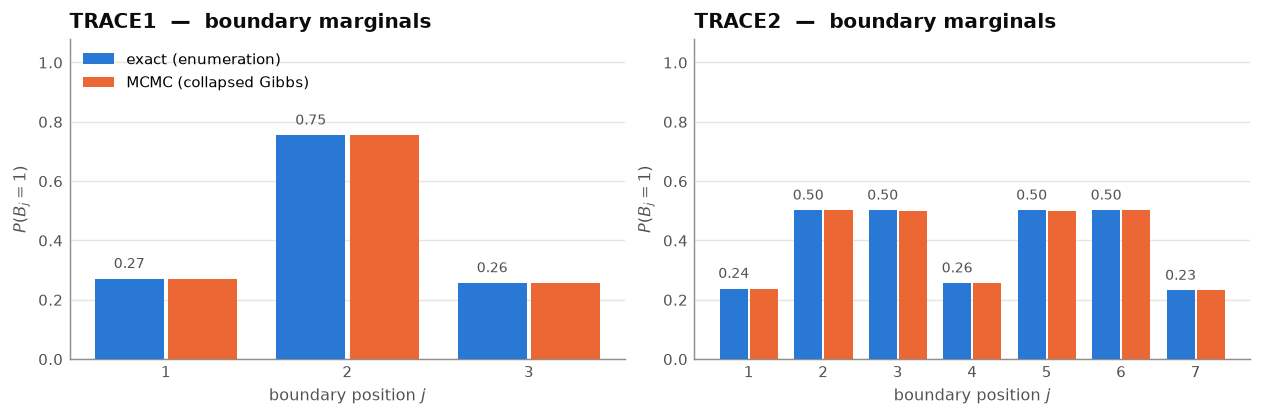

In [12]:
def fig_boundaries(res, ax):
    T = res["T"]
    x = np.arange(1, T)
    wid = 0.38
    ex, mc = res["ex"]["pB"], res["pB_mc"]
    ax.bar(x - wid/2 - 0.012, ex, wid, color=S1, label="exact (enumeration)", zorder=3)
    ax.bar(x + wid/2 + 0.012, mc, wid, color=S2, label="MCMC (collapsed Gibbs)", zorder=3)
    ax.set_xticks(x); ax.set_xlabel("boundary position $j$"); ax.set_ylim(0, 1.08)
    ax.set_ylabel("$P(B_j = 1)$")
    ax.yaxis.grid(True, zorder=0); ax.set_axisbelow(True)
    ax.set_title(f"{res['name']}  —  boundary marginals")
    for xi, v in zip(x, ex):                                  # direct-label the exact bars only
        ax.text(xi - wid/2 - 0.012, v + 0.025, f"{v:.2f}", ha="center", va="bottom",
                fontsize=7.5, color=INK2)
    return ax

fig, axes = plt.subplots(1, 2, figsize=(9.6, 3.1), constrained_layout=True)
fig_boundaries(r1, axes[0]); fig_boundaries(r2, axes[1])
axes[0].legend(loc="upper left", bbox_to_anchor=(0, 1.0))
plt.show()

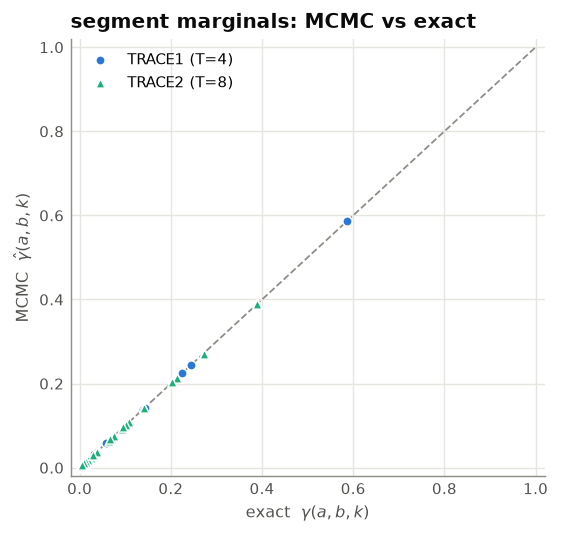

In [13]:
fig, ax = plt.subplots(figsize=(4.2, 4.0), constrained_layout=True)
ax.plot([0, 1], [0, 1], color=INK3, lw=1.0, ls="--", zorder=1)
for res, col, mk, lab in [(r1, S1, "o", "TRACE1 (T=4)"), (r2, S3, "^", "TRACE2 (T=8)")]:
    g_ex, g_mc = res["ex"]["gamma"].ravel(), res["gamma_mc"].ravel()
    m = g_ex > 1e-4
    ax.scatter(g_ex[m], g_mc[m], s=26, marker=mk, facecolor=col,
               edgecolor="white", linewidth=0.8, zorder=3, label=lab)
ax.set_xlabel(r"exact  $\gamma(a,b,k)$"); ax.set_ylabel(r"MCMC  $\hat\gamma(a,b,k)$")
ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)
ax.grid(True, zorder=0); ax.set_axisbelow(True)
ax.set_title("segment marginals: MCMC vs exact")
ax.legend(loc="upper left")
plt.show()

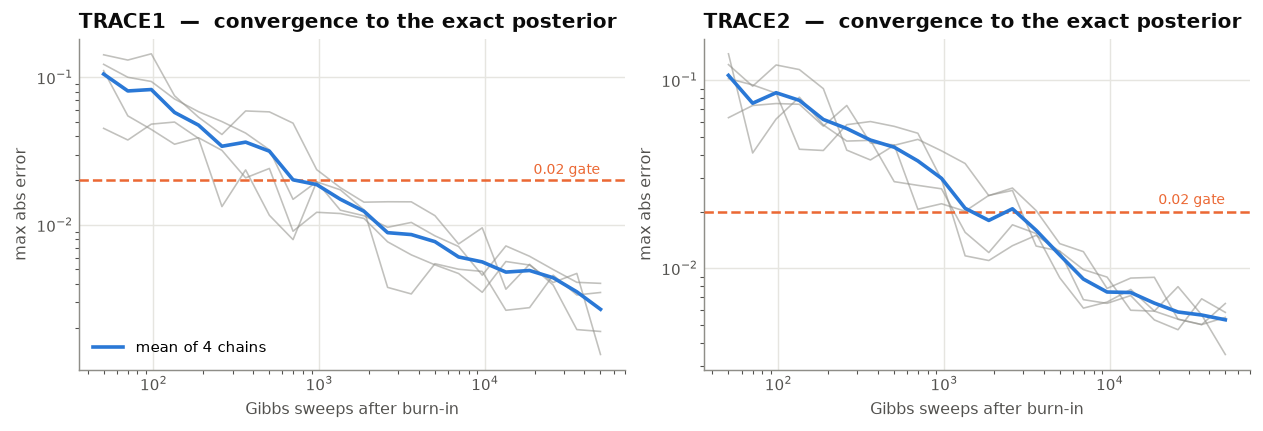

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(9.6, 3.2), constrained_layout=True)
for ax, res in zip(axes, (r1, r2)):
    ns = CHECKPOINTS
    per_chain = []
    for ch in res["chains"]:
        e = [max(max_abs(ch["ckpt"][n][0], res["ex"]["pB"]),
                 max_abs(ch["ckpt"][n][1], res["ex"]["gamma"])) for n in ns]
        per_chain.append(e)
        ax.plot(ns, e, color=INK3, lw=0.9, alpha=0.55, zorder=2)
    ax.plot(ns, np.mean(per_chain, axis=0), color=S1, zorder=4, label="mean of 4 chains")
    ax.axhline(0.02, color=S2, lw=1.4, ls="--", zorder=3)
    ax.text(ns[-1], 0.021, "0.02 gate", ha="right", va="bottom", fontsize=8, color=S2)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("Gibbs sweeps after burn-in"); ax.set_ylabel("max abs error")
    ax.grid(True, which="major", zorder=0); ax.set_axisbelow(True)
    ax.set_title(f"{res['name']}  —  convergence to the exact posterior")
axes[0].legend(loc="lower left")
plt.show()

## 8. Gate — 成功标准

Both criteria, on both traces. `FAIL` here means **stop**: no later experiment is
interpretable if the posterior machinery is wrong.

In [15]:
rows = []
for res in (r1, r2):
    rows.append(dict(
        trace=res["name"], T=res["T"], n_states=res["ex"]["n_states"],
        dp_logZ=res["err_dp_logZ"], dp_pB=res["err_dp_pB"], dp_gamma=res["err_dp_gamma"],
        mc_pB=res["err_mc_pB"], mc_gamma=res["err_mc_gamma"], tv=res["tv"],
        passed=bool(res["passed"])))

hdr = f"{'trace':<8}{'T':>3}{'states':>8}{'|dlogZ|dp':>12}{'|dgam|dp':>11}" \
      f"{'|dP(B)|mc':>12}{'|dgam|mc':>11}{'TV':>9}{'gate':>8}"
print(hdr); print("-" * len(hdr))
for r in rows:
    print(f"{r['trace']:<8}{r['T']:>3}{r['n_states']:>8}{r['dp_logZ']:>12.2e}"
          f"{r['dp_gamma']:>11.2e}{r['mc_pB']:>12.4f}{r['mc_gamma']:>11.4f}"
          f"{r['tv']:>9.4f}{'PASS' if r['passed'] else 'FAIL':>8}")

ALL_PASS = all(r["passed"] for r in rows)
print()
print(("EXPERIMENT 0 PASSED — exact enumeration == DP (machine precision), "
       "MCMC == exact (< 0.02).") if ALL_PASS else
      "EXPERIMENT 0 FAILED — do not proceed to later experiments.")
assert ALL_PASS

trace     T  states   |dlogZ|dp   |dgam|dp   |dP(B)|mc   |dgam|mc       TV    gate
----------------------------------------------------------------------------------
TRACE1    4      54    1.78e-15   3.89e-16      0.0006     0.0005   0.0016    PASS
TRACE2    8    4374    2.84e-14   1.04e-14      0.0017     0.0021   0.0086    PASS

EXPERIMENT 0 PASSED — exact enumeration == DP (machine precision), MCMC == exact (< 0.02).


In [16]:
out = Path("../data/experiments/exp0")
out.mkdir(parents=True, exist_ok=True)
payload = dict(
    config=dict(vocab=VOCAB, skills=SKILLS, phi=PHI.tolist(), pi=PI.tolist(), rho=RHO,
                n_chains=N_CHAINS, n_sweeps=N_SWEEPS, burn_in=1000, seed=SEED),
    results=rows,
    traces={r["name"]: dict(
        trace=r["trace"],
        pB_exact=r["ex"]["pB"].tolist(), pB_mcmc=r["pB_mc"].tolist(),
        logZ=r["ex"]["logZ"], map=fmt_state(*r["ex"]["map_state"]),
        map_prob=r["ex"]["map_prob"]) for r in (r1, r2)},
    all_pass=ALL_PASS)
(out / "exp0_results.json").write_text(json.dumps(payload, indent=2))
print("wrote", (out / "exp0_results.json").resolve())

wrote /Users/dongqing/Desktop/hpop/data/experiments/exp0/exp0_results.json


## Appendix A — the no-self-transition variant (and a check on the repo's lattice)

Section 3 showed the main model is non-identifiable: with self-transitions allowed,
$(1,1,A)|(2,2,A)$ and $(1,2,A)$ are likelihood-equivalent. `hpop.inference.semi_markov`
already assumes the canonical convention $z_l \ne z_{l+1}$ (Assumption
`ass:no-self-transition`), which removes exactly this degeneracy.

Same data, same $\phi$, same boundary prior — but restricted to label sequences with no
adjacent repeats. Feeding

$$
\text{scores}[a{-}1,\,w{-}1,\,k]\;=\;\log\pi_k+\sum_{t=a}^{a+w-1}\log\phi_{k,c_t}
+(w{-}1)\log(1{-}\rho)+\log\rho\cdot\mathbb{1}[a{+}w{-}1<T]
$$

into `SemiMarkovLattice` must reproduce brute-force enumeration under the same constraint.
That validates the production code path on Experiment 0's data.

In [17]:
import sys
sys.path.insert(0, "../src")
from hpop.inference.semi_markov import SemiMarkovLattice, brute_force_marginals, brute_force_log_partition

def build_scores(c):
    """scores[i, w-1, k] over single-action seeds; D_max = T."""
    T, LL = len(c), seg_loglik_table(c)
    sc = np.full((T, T, K), -np.inf)
    for a in range(1, T + 1):
        for w in range(1, T - a + 2):
            b = a + w - 1
            sc[a - 1, w - 1] = (LOG_PI + LL[a - 1, b - 1]
                                + (w - 1) * LOG_1MRHO + (LOG_RHO if b < T else 0.0))
    return sc

for name, trace in [("TRACE1", TRACE1), ("TRACE2", TRACE2)]:
    sc = build_scores(encode(trace))
    lat = SemiMarkovLattice(sc)
    mu, bf = lat.segment_marginals(), brute_force_marginals(sc)
    dz = abs(lat.log_partition() - brute_force_log_partition(sc))
    print(f"{name}: lattice vs brute force  |dlogZ|={dz:.2e}  max|dmu|={max_abs(mu, bf):.2e}")
    assert dz < 1e-9 and max_abs(mu, bf) < 1e-9
print("\nSemiMarkovLattice reproduces brute-force enumeration under z_l != z_{l+1}.")

TRACE1: lattice vs brute force  |dlogZ|=8.88e-16  max|dmu|=5.55e-16
TRACE2: lattice vs brute force  |dlogZ|=0.00e+00  max|dmu|=6.66e-16

SemiMarkovLattice reproduces brute-force enumeration under z_l != z_{l+1}.


In [18]:
# how much does the constraint change the answer? (TRACE1 boundary marginals)
sc = build_scores(encode(TRACE1))
mu = SemiMarkovLattice(sc).segment_marginals()          # mu[i, w-1, k]
T = len(TRACE1)
pB_nst = np.zeros(T - 1)
for i in range(T):
    for w in range(1, T - i + 1):
        b = i + w                                        # 1-based end position
        if b < T:
            pB_nst[b - 1] += mu[i, w - 1].sum()

print("TRACE1, P(B_j = 1)")
print(f"   {'j':>3}  {'self-trans allowed':>20}  {'z_l != z_{l+1}':>16}")
for j in range(T - 1):
    print(f"   {j+1:>3}  {r1['ex']['pB'][j]:>20.4f}  {pB_nst[j]:>16.4f}")
print("\nThe spurious boundaries at j=1,3 collapse once self-transitions are banned:")
print("the segmentation becomes identifiable, which is why HPOP adopts the convention.")

TRACE1, P(B_j = 1)
     j    self-trans allowed    z_l != z_{l+1}
     1                0.2712            0.1207
     2                0.7549            0.7190
     3                0.2570            0.1040

The spurious boundaries at j=1,3 collapse once self-transitions are banned:
the segmentation becomes identifiable, which is why HPOP adopts the convention.


## What Experiment 0 established

1. **The joint is written once** (`log_joint`) and three engines consume it, so agreement is
   evidence about the *algorithms*, not about a shared re-derivation.
2. **DP == enumeration** to $\sim10^{-16}$ on both traces — the $O(T^2K)$ semi-Markov
   forward–backward is a correct marginalizer, including the boundary-prior factorization
   $\sum_{\text{segments}}(\cdot)=\log p(B)$.
3. **Collapsed Gibbs == exact** within the 0.02 gate on both traces, including the
   multimodal $T=8$ case; the convergence plot shows the error decaying at the
   $O(N^{-1/2})$ Monte-Carlo rate, so the gate is a sample-size question, not a bias.
4. **A modelling fact fell out**: without $z_l\ne z_{l+1}$ the segmentation is not
   identifiable — boundary marginals at "internal" positions are prior-driven artefacts.
   Appendix A confirms the repo's `SemiMarkovLattice` implements the constrained model
   correctly, again against brute force.

Next: swap the bag-of-actions segment likelihood for the order-sensitive one
(`hpop.inference.likelihood.frontier_softmax_logp`) and re-run the same three-engine
check — the enumeration harness here is the reusable part.